In [1]:
print('hello')

hello


In [7]:
from langgraph.graph import StateGraph,START,END
from langchain_openrouter import ChatOpenRouter
from typing import TypedDict,Literal
from dotenv import load_dotenv
from pydantic import BaseModel , Field

In [3]:
load_dotenv()

True

In [4]:
import os

os.environ['OPENROUTER_API_KEY'] = os.getenv('OPENROUTER_API_KEY')

In [20]:
model = ChatOpenRouter(
    model="qwen/qwen3-32b",
    temperature=0,
)

reply_model = ChatOpenRouter(
    model = 'qwen/qwen3-32b',
    temperature=0.3
)

In [35]:
class SentimentSchema(BaseModel):

    sentiment: Literal["positive","negative","neutral"] = Field(description="Sentiment of the review")

In [24]:
class DiagnosisSchema(BaseModel):
    issue_type:Literal["UX","Performance","Bug","Support","Refund","Other"] = Field(description='The Issue type of the negative Review')
    tone:Literal["angry","frustrated","disappointed","calm"] = Field(description='The emotional tone of the User')
    urgency:Literal["Low","Medium","High"] = Field("How urgent or critical the issue appears to be")

In [36]:
structured_model = model.with_structured_output(SentimentSchema)

In [25]:
diagnosis_model = reply_model.with_structured_output(DiagnosisSchema)

In [38]:
prompt = "The product quality is excellent, but the delivery was delayed by a week."
structured_model.invoke(prompt)

SentimentSchema(sentiment='neutral')

In [39]:
class ReviewState(TypedDict):
    review : str
    sentiment:Literal["positive","negative","neutral"]
    diagnosis:dict
    response:str


In [40]:
def find_sentiment(state:ReviewState)-> ReviewState:
    prompt=f"""for the following review analysis and give me the Sentiment(postive or negative):
    - review: {state['review']}
    """

    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment':sentiment}


In [41]:
def check_condition(state:ReviewState):
    if state['sentiment'] == 'positive':
        return "positive"
    elif state['sentiment'] == 'neutral':
        return "neutral"
    else:
        return "negative"

In [42]:
def positive_response(state:ReviewState) -> ReviewState:
    prompt=f""" Write a warm thank you message in response to this review:\n\n
    - Review: {state['review']},
    Also, kindly ask the user to leave feedback on our website,follow the social media pages!!
    """
    response = reply_model.invoke(prompt).content

    return {'response':response}

def run_diagnosis(state:ReviewState) -> ReviewState:
    prompt = f"""
    Diagnose this negative review:\n\n 
    - Review : {state['review']}\n
    Return issue type , tone and urgency
    """
    diagnose = diagnosis_model.invoke(prompt)

    return {'diagnosis':dict(diagnose)}


def negative_response(state:ReviewState) -> ReviewState:
    diagnosis = state['diagnosis']
    
    prompt = f"""You are a support assistent.
    The user had a '{diagnosis['issue_type']}' issue ,sounded '{diagnosis['tone']}' , and \n 
    marked urgency as '{diagnosis['urgency']}'.
    Write a empathethic , helpful resolution message!
    """

    response = reply_model.invoke(prompt).content

    return {'response':response}

def neutral_response(state:ReviewState) -> ReviewState:
    prompt = f"""
    Write a friendly response to this review:

    Review: {state['review']}

    Thank the user for their feedback. Mention that their input helps us improve our products and services. Kindly ask them to leave more detailed feedback on our website and follow our social media pages for future updates.
    """

    response = reply_model.invoke(prompt).content

    return {'response':response}

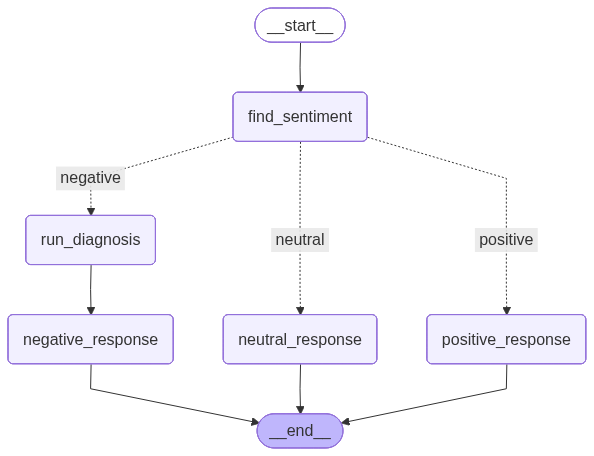

In [43]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment',find_sentiment)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('positive_response',positive_response)
graph.add_node('negative_response',negative_response)
graph.add_node('neutral_response',neutral_response)

graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_condition,{
    'positive':'positive_response',
    'negative':'run_diagnosis',
    'neutral':'neutral_response'
})
graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)
graph.add_edge('neutral_response',END)

app = graph.compile()
app

In [31]:
initial_state = {
    "review": "Excellent product! The build quality is amazing and delivery was super fast."
}
output = app.invoke(initial_state)
print(output['response'])

**Subject:** Thank You for Your Excellent Feedback! 🌟  

Dear [Customer's Name],  

Thank you so much for taking the time to share your kind words! We’re absolutely thrilled to hear that you’re happy with the product’s build quality and the speed of your delivery. Your satisfaction truly means the world to us! 😊  

We’d love to hear more about your experience on our website—your feedback helps us continue improving and serving you better. Plus, we’d be honored if you’d consider following our social media pages for updates, special offers, and more! [Insert Social Media Links Here]  

If you ever need assistance or have any questions, don’t hesitate to reach out. We’re always here to help!  

Warm regards,  
[Your Name]  
[Your Position]  
[Company Name]  
[Website Link] | [Social Media Links]  

P.S. Wishing you many more happy moments with your new product! 🎉  

---  
*Note: Replace placeholders (e.g., [Customer's Name], [Your Name], etc.) with personalized details before sending.*


In [33]:
initial_state = {
    "review": "The product was worst! It stopped working after two days."
}
output = app.invoke(initial_state)
print(output['diagnosis'])
print(output['response'])

{'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'High'}
**Subject:** Resolving Your Urgent Issue – We’re Here to Help!  

Hi [User's Name],  

I’m truly sorry to hear about the bug you’re experiencing – I completely understand how frustrating that can be, especially when time is of the essence. Thank you for flagging this as high urgency; I’m here to ensure we resolve it as quickly as possible.  

Could you please share a few more details to help me pinpoint the issue? For example:  
- What specific action or error are you encountering?  
- When did this start happening?  
- Have you tried any troubleshooting steps already?  

Once I have this information, I’ll prioritize a solution and keep you updated every step of the way. If this requires deeper investigation, I’ll escalate it to our specialists immediately and provide a timeline for resolution.  

You’re not alone in this – we’ll get it fixed! Thank you for your patience and for bringing this to our attention. I’m looking f

In [45]:
initial_state = {
    "review": "The product is okay. It performs as expected but nothing exceptional."
}

output = app.invoke(initial_state)
output

{'review': 'The product is okay. It performs as expected but nothing exceptional.',
 'sentiment': 'neutral',
 'response': '**Hi [Name],**  \n\nThank you for taking the time to share your feedback with us! We truly appreciate your honest perspective, and it means a lot that you found the product to perform as expected. Your input is invaluable as we strive to continuously improve our offerings and better meet the needs of our customers.  \n\nIf you’re willing, we’d love to hear more detailed thoughts on our website—your insights could help us refine future updates and enhance your experience even further. Don’t forget to follow us on social media for the latest news, promotions, and product developments!  \n\nWe’re always here to help, so feel free to reach out if you have any questions or need assistance. Thank you again for being part of our journey! 😊  \n\nBest regards,  \n[Your Name/Team Name]  \n[Company Name]'}

In [46]:
initial_state = {
    "review": "Customer support was fantastic, but the product itself feels cheaply made."
}

output = app.invoke(initial_state)
output

{'review': 'Customer support was fantastic, but the product itself feels cheaply made.',
 'sentiment': 'neutral',
 'response': '**Response:**  \n\nThank you so much for taking the time to share your feedback! We’re thrilled to hear that our customer support team was able to assist you and provide a positive experience.  \n\nRegarding the product quality, we sincerely apologize for the disappointment. Your input is incredibly valuable to us, as it helps us identify areas for improvement and work toward better solutions. To ensure we address your concerns thoroughly, we’d greatly appreciate it if you could share more detailed feedback directly on our website.  \n\nWe also invite you to follow our social media pages for updates, special offers, and insights into upcoming improvements. Your support means a lot, and we’re committed to earning your trust. If you need further assistance, feel free to reach out—we’re here to help!  \n\nWarm regards,  \n[Your Name/Team Name]  \n[Company Name]'}

In [48]:
review="""
User: Sarah Johnson

I've been using this app for almost three months now, and I must say it has exceeded my expectations. The interface is clean, easy to navigate, and the features are actually useful rather than being just marketing gimmicks. I especially appreciate how responsive the app is, even on my older device. Customer support was also fantastic when I had a small issue with my account—they responded within a few hours and resolved everything quickly. The recent updates have added some great improvements without making the app feel cluttered. Overall, this has become one of the few apps I use every day. Highly recommended to anyone looking for a reliable and user-friendly experience.
"""

In [49]:
initial_state = {
    "review": review
}

output = app.invoke(initial_state)
output

{'review': "\nUser: Sarah Johnson\n\nI've been using this app for almost three months now, and I must say it has exceeded my expectations. The interface is clean, easy to navigate, and the features are actually useful rather than being just marketing gimmicks. I especially appreciate how responsive the app is, even on my older device. Customer support was also fantastic when I had a small issue with my account—they responded within a few hours and resolved everything quickly. The recent updates have added some great improvements without making the app feel cluttered. Overall, this has become one of the few apps I use every day. Highly recommended to anyone looking for a reliable and user-friendly experience.\n",
 'sentiment': 'positive',
 'response': '**Subject:** Heartfelt Thanks from Our Team!  \n\nDear Sarah Johnson,  \n\nThank you so much for taking the time to share your thoughtful review! We’re absolutely thrilled to hear that your experience with our app has been so positive ove